In [39]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
#for dirname, _, filenames in os.walk('/kaggle/input'):
#    for filename in filenames:
#        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session
current_directory = os.getcwd()
print("Current working directory:", current_directory)
os.chdir("/kaggle/input/histopathologic-cancer-detection/")
print("Current working directory:", current_directory)
os.listdir(current_directory)

Current working directory: /kaggle/input/histopathologic-cancer-detection
Current working directory: /kaggle/input/histopathologic-cancer-detection


['sample_submission.csv', 'train_labels.csv', 'test', 'train']

In [43]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

## Loading data and EDA

In [16]:
labels_df = pd.read_csv('train_labels.csv')
#print summary of training labels document
labels_df.describe()
print(labels_df.head())
labels_df.info()

                                         id  label
0  f38a6374c348f90b587e046aac6079959adf3835      0
1  c18f2d887b7ae4f6742ee445113fa1aef383ed77      1
2  755db6279dae599ebb4d39a9123cce439965282d      0
3  bc3f0c64fb968ff4a8bd33af6971ecae77c75e08      0
4  068aba587a4950175d04c680d38943fd488d6a9d      0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220025 entries, 0 to 220024
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   id      220025 non-null  object
 1   label   220025 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 3.4+ MB


### Plotting initial figures from the test dataset

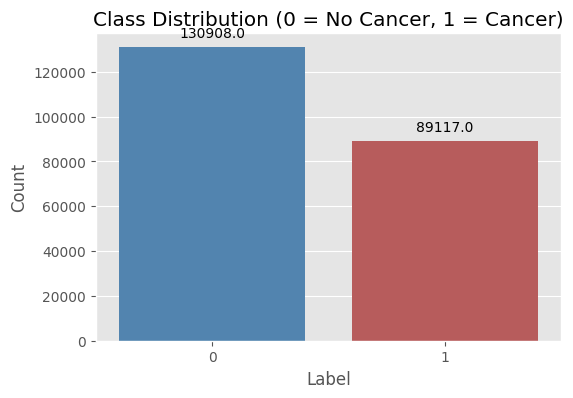

In [17]:
import seaborn as sns

# Set plotting style
plt.style.use('ggplot')

# Plot the distribution of labels
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='label', data=labels_df, palette=['#4385be', '#c64d4d'])
plt.title('Class Distribution (0 = No Cancer, 1 = Cancer)')
plt.xlabel('Label')
plt.ylabel('Count')

# Add counts on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 10), textcoords = 'offset points')
plt.show()

#### There seems to be significantly more false (0) cases than positive cases (1) in the training dataset

In [22]:
# Change labels to strings for the imageDataGenerator 
labels_df['label'] = labels_df['label'].astype(str)

# Add the '.tif' extension to the id for filename matching
labels_df['id'] = labels_df['id'] + '.tif'

subset_fraction = 0.1
labels_df = labels_df.sample(frac=subset_fraction, random_state=42)
print(f"Subset created with {len(labels_df)} images.")

print(f"Loaded {len(labels_df)} labels. Positive samples: {labels_df['label'].value_counts()['1']}")
print(f"Negative samples: {labels_df['label'].value_counts()['0']}")

# --- Train / Validation Split ---
# We split the dataframe to create a validation set.
# Stratify ensures the split has a similar proportion of positive/negative samples.
train_df, val_df = train_test_split(labels_df, test_size=0.2, random_state=42, stratify=labels_df['label'])

print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")

Subset created with 2200 images.
Loaded 2200 labels. Positive samples: 861
Negative samples: 1339
Training samples: 1760
Validation samples: 440


#### In the code above, I reduced the number of test cases to train the model on so that I'm only training on 10% of the original test dataset. I am also changing the variable type of the 'id' variable from integer to sting for easier data processing later on.


More dimension analysis going on here. I want to check the size of the images. Below I just sampled of the one images from the folder. 

In [23]:
#load constants
TRAIN_DIR = 'train/'
TEST_DIR = 'test/'
WORKING_DIR  = '/kaggle/working/'
IMAGE_SIZE = 96  
BATCH_SIZE = 64

#check the dimensions of the images themselves.

# Get a sample image filename from the train directory
sample_image_name = os.listdir(TRAIN_DIR)[0]
sample_image_path = os.path.join(TRAIN_DIR, sample_image_name)

# Load the image and get its shape
image = tf.keras.preprocessing.image.load_img(sample_image_path)
image_array = tf.keras.preprocessing.image.img_to_array(image)

print(f"--- Image Info ---")
print(f"Image dimensions (Height, Width, Channels): {image_array.shape}")

--- Image Info ---
Image dimensions (Height, Width, Channels): (96, 96, 3)


#### Here I am displaying a few of the images from each of the 2 classes to help visualize the core of the project.

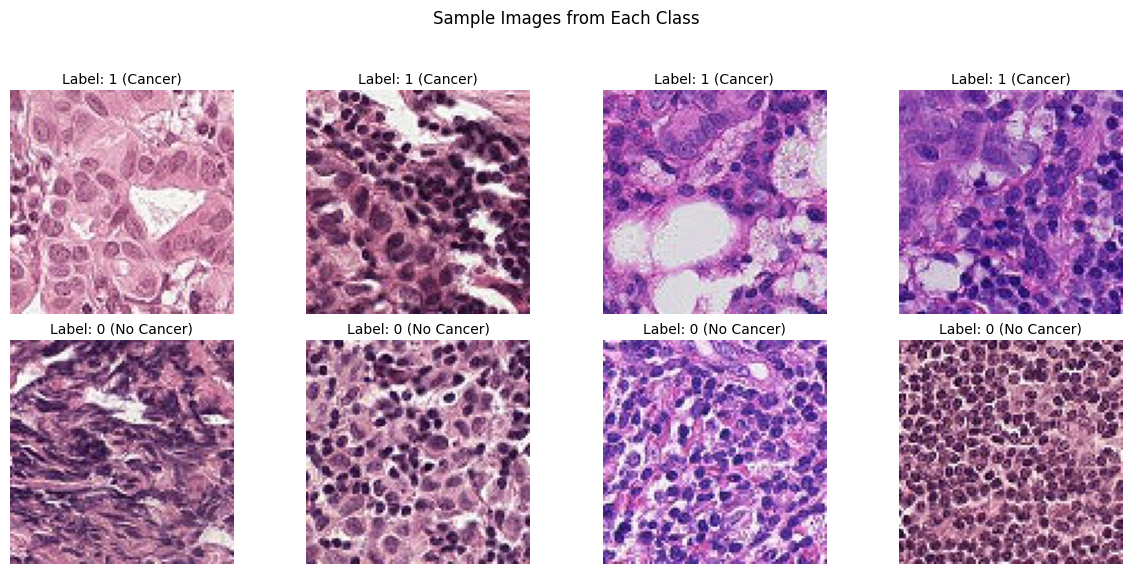

In [24]:
# Display sample images
positive_samples = labels_df[labels_df['label'] == '1'].sample(4, random_state=42)
negative_samples = labels_df[labels_df['label'] == '0'].sample(4, random_state=42)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

# Plot positive samples
for i, row in enumerate(positive_samples.itertuples()):
    img_path = os.path.join(TRAIN_DIR, f"{row.id}")
    img = plt.imread(img_path)
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Label: 1 (Cancer)", fontsize=10)
    axes[0, i].axis('off')

# Plot negative samples
for i, row in enumerate(negative_samples.itertuples()):
    img_path = os.path.join(TRAIN_DIR, f"{row.id}")
    img = plt.imread(img_path)
    axes[1, i].imshow(img)
    axes[1, i].set_title(f"Label: 0 (No Cancer)", fontsize=10)
    axes[1, i].axis('off')

plt.suptitle("Sample Images from Each Class")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Data augmentation
Data augmentation creates modified versions of the training images (rotated, flipped, etc.), which helps prevent overfitting and makes the model generalize better to new data.

In [25]:
# --- Create Data Generators ---

# For the training data, we apply augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255.,          # Normalize pixel values to [0, 1]
    rotation_range=20,        # Randomly rotate images
    width_shift_range=0.1,    # Randomly shift images horizontally
    height_shift_range=0.1,   # Randomly shift images vertically
    horizontal_flip=True,     # Randomly flip images horizontally
    vertical_flip=True,       # Randomly flip images vertically
    fill_mode='nearest'
)

# For validation data, we ONLY rescale. No augmentation.
val_datagen = ImageDataGenerator(rescale=1./255.)

# Create generators that flow data from the dataframe
print("Creating train generator...")
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=TRAIN_DIR,
    x_col='id',
    y_col='label',
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

print("Creating validation generator...")
validation_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=TRAIN_DIR,
    x_col='id',
    y_col='label',
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False # No need to shuffle validation data
)

Creating train generator...
Found 1760 validated image filenames belonging to 2 classes.
Creating validation generator...
Found 440 validated image filenames belonging to 2 classes.


## Building the CNN Model
The model follows a standard pattern of stacking Conv2D and MaxPooling2D layers. Batch Normalization is used to stabilize and speed up training, and Dropout is a regularization technique to prevent overfitting.

The final layer uses a sigmoid activation function, which outputs a probability between 0 and 1, perfect for binary classification.

In [26]:
# Build the CNN Model
model = Sequential([
    # First convolutional block
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Second convolutional block
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Third convolutional block
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    # Flatten the feature maps to a 1D vector
    Flatten(),
    
    # Dense layers for classification
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5), # Dropout for regularization
    
    # Output layer
    Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 94, 94, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 45, 45, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 20, 20, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     6,554,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,650,817 (25.37 MB)

 Trainable params: 6,649,345 (25.37 MB)

 Non-trainable params: 1,472 (5.75 KB)

### Training the model
I chose to use a ModelCheckpoint callback. This is extremely important because it saves the model's weights only when it improves on a monitored metric (like validation accuracy), ensuring we keep the best version of our model.

In [27]:
model_save_path = '/kaggle/working/best_model.h5' 
# Callback to save the best model to the specified path
checkpoint = ModelCheckpoint(model_save_path, 
                             monitor='val_accuracy', 
                             verbose=1, 
                             save_best_only=True, 
                             mode='max')

history = model.fit(
    train_generator,
    steps_per_epoch=len(train_df) // BATCH_SIZE,
    epochs=15, # Adjust as needed
    validation_data=validation_generator,
    validation_steps=len(val_df) // BATCH_SIZE,
    callbacks=[checkpoint]
)

# When you load the model in Step 5, remember to use the same full path:
# model.load_weights('/kaggle/working/best_model.h5')

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6852 - loss: 0.9873
Epoch 1: val_accuracy improved from -inf to 0.62500, saving model to /kaggle/working/best_model.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.6867 - loss: 0.9784 - val_accuracy: 0.6250 - val_loss: 0.7321
Epoch 2/15
 1/27 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.7656 - loss: 0.4793

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.62500
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.7656 - loss: 0.4793 - val_accuracy: 0.6250 - val_loss: 0.7345
Epoch 3/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7850 - loss: 0.4983
Epoch 3: val_accuracy did not improve from 0.62500
27/27 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.7852 - loss: 0.4979 - val_accuracy: 0.5729 - val_loss: 0.6866
Epoch 4/15
 1/27 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.7812 - loss: 0.4939
Epoch 4: val_accuracy did not improve from 0.62500
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.7812 - loss: 0.4939 - val_accuracy: 0.5807 - val_loss: 0.6901
Epoch 5/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7922 - loss: 0.4873
Epoch 5: val_accuracy did not improve from 0.62500
27/27 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.7923 - loss: 0.4871 - val_accuracy: 0.5599 - val_loss: 0.8324
Epoch 6/15
 1/27 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.7969 - loss: 0.4661

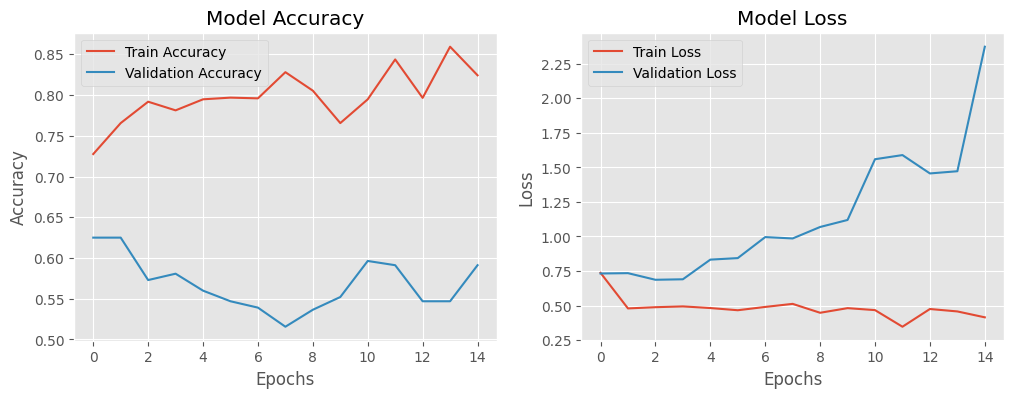

Found 57458 validated image filenames.
898/898 ━━━━━━━━━━━━━━━━━━━━ 391s 435ms/step
Submission file created successfully in /kaggle/working/!


In [34]:
# --- Plot Training History ---
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Prediction on Test Data 
FULL_TEST_DIR = "/kaggle/input/histopathologic-cancer-detection/test"

# Load the best performing model from the writable directory
model.load_weights('/kaggle/working/best_model.h5')

test_filenames = os.listdir(FULL_TEST_DIR)
test_df = pd.DataFrame({'id': test_filenames})

# Test generator should NOT shuffle
test_datagen = ImageDataGenerator(rescale=1./255.)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    # Provide the full, correct path to the test images
    directory=FULL_TEST_DIR,
    x_col='id',
    y_col=None, # No labels for test data
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode=None,
    shuffle=False
)

# Generate predictions
predictions = model.predict(test_generator, steps=len(test_df) // BATCH_SIZE + 1)

# Format for submission
submission_df = pd.DataFrame()
# Remove the '.tif' extension for the submission file
submission_df['id'] = test_df['id'].str.replace('.tif', '')
submission_df['label'] = predictions.flatten() # Flatten the predictions to a 1D array

# Save the submission file in the writable directory
submission_df.to_csv('/kaggle/working/submission.csv', index=False)



## Based on the graphs and logs, the model is showing signs of severe overfitting.

In the Accuracy plot, the Train Accuracy (red) steadily increases, while the Validation Accuracy (blue) is erratic and stays low. This means the model is getting great at classifying images it has already seen but is failing to generalize to new ones.

In the Loss plot, the Train Loss (red) consistently decreases, but the Validation Loss (blue) starts to increase dramatically after epoch 3. This is the clearest sign that the model has begun to memorize noise from the training data instead of learning general features.

The training logs show that val_accuracy did not improve from 0.62500 after the first couple of epochs. This confirms that the model's best performance was achieved very early in training.

### Correcting the model and rerunning.

Overfitting can also mean the model is too complex for the amount of data. A simpler model has less capacity to memorize noise.

I plan on reducing the Dense Layer Size. I will change it from Dense(512, ...) to Dense(256, ...).

I am removing a Conv block so I will have 2 instead of 3.

I will also be adding another dropout after the second conv. layer as a regulation technique.

Adding Early Stopping will automatically stop the training when the validation loss stops improving.

In [44]:
# Build the CNN Model - Part 2
model = Sequential([
    # First convolutional block
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Second convolutional block
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    # Removing Third convolutional block
    #Conv2D(128, (3, 3), activation='relu'),
    #BatchNormalization(),
    #MaxPooling2D((2, 2)),
    
    # Flatten the feature maps to a 1D vector
    Flatten(),
    
    # Dense layers for classification
    # updating Dense 512 to Dense 256
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5), # Dropout for regularization
    
    # Output layer
    Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

from tensorflow.keras.callbacks import ReduceLROnPlateau





/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 94, 94, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 45, 45, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     7,930,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,951,169 (30.33 MB)

 Trainable params: 7,950,465 (30.33 MB)

 Non-trainable params: 704 (2.75 KB)

#### Using a scheduler that reduces the learning rate when performance plateaus can help. This library can help: from tensorflow.keras.callbacks import ReduceLROnPlateau
I am also using the from tensorflow.keras.callbacks import EarlyStopping library where I can implement early stopping if the model performance is not improving after a number of epochs.

In [46]:

lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.00001)

# Stop training when 'val_loss' has not improved in 3 epochs
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model_save_path = '/kaggle/working/best_model_run2.h5' 
# Callback to save the best model to the specified path
checkpoint = ModelCheckpoint(model_save_path, 
                             monitor='val_accuracy', 
                             verbose=1, 
                             save_best_only=True, 
                             mode='max')

history = model.fit(
    train_generator,
    steps_per_epoch=len(train_df) // BATCH_SIZE,
    epochs=15, # Adjust as needed
    validation_data=validation_generator,
    validation_steps=len(val_df) // BATCH_SIZE,
    callbacks=[checkpoint,early_stopping, lr_scheduler] ## adding lr_scheduler to the callbacks list
)

Epoch 1/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 970ms/step - accuracy: 0.6800 - loss: 1.0412
Epoch 1: val_accuracy improved from -inf to 0.62760, saving model to /kaggle/working/best_model_run2.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.6809 - loss: 1.0312 - val_accuracy: 0.6276 - val_loss: 0.6845 - learning_rate: 0.0010
Epoch 2/15
 1/27 ━━━━━━━━━━━━━━━━━━━━ 24s 943ms/step - accuracy: 0.8281 - loss: 0.4839

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.62760
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.8281 - loss: 0.4839 - val_accuracy: 0.6276 - val_loss: 0.6979 - learning_rate: 0.0010
Epoch 3/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7400 - loss: 0.5850
Epoch 3: val_accuracy did not improve from 0.62760
27/27 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.7402 - loss: 0.5847 - val_accuracy: 0.5990 - val_loss: 0.6630 - learning_rate: 0.0010
Epoch 4/15
 1/27 ━━━━━━━━━━━━━━━━━━━━ 25s 962ms/step - accuracy: 0.7656 - loss: 0.5041
Epoch 4: val_accuracy did not improve from 0.62760
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.7656 - loss: 0.5041 - val_accuracy: 0.5859 - val_loss: 0.6649 - learning_rate: 0.0010
Epoch 5/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 986ms/step - accuracy: 0.7845 - loss: 0.4773
Epoch 5: val_accuracy did not improve from 0.62760
27/27 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.7841 - loss: 0.4787 - val_accuracy: 0.5469 - val_loss: 0.9978 - lea

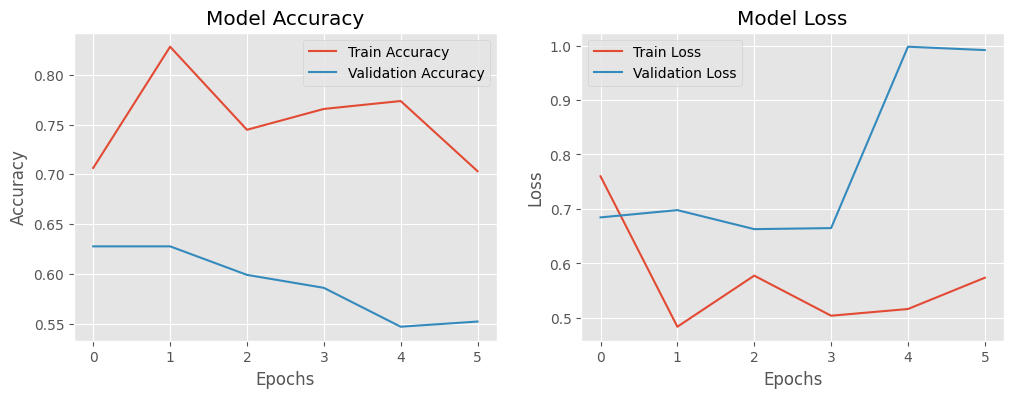

Found 57458 validated image filenames.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


898/898 ━━━━━━━━━━━━━━━━━━━━ 185s 205ms/step


In [47]:
# Plot Training History part 2
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Prediction on Test Data
FULL_TEST_DIR = "/kaggle/input/histopathologic-cancer-detection/test"

# Load the best performing model from the writable directory
model.load_weights('/kaggle/working/best_model_run2.h5')

test_filenames = os.listdir(FULL_TEST_DIR)
test_df = pd.DataFrame({'id': test_filenames})

# Test generator should NOT shuffle
test_datagen = ImageDataGenerator(rescale=1./255.)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    # Provide the full, correct path to the test images
    directory=FULL_TEST_DIR,
    x_col='id',
    y_col=None, # No labels for test data
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode=None,
    shuffle=False
)

# Generate predictions
predictions = model.predict(test_generator, steps=len(test_df) // BATCH_SIZE + 1)

# Format for submission
submission_df = pd.DataFrame()
# Remove the '.tif' extension for the submission file
submission_df['id'] = test_df['id'].str.replace('.tif', '')
submission_df['label'] = predictions.flatten() # Flatten the predictions to a 1D array

# Save the submission file in the writable directory
submission_df.to_csv('/kaggle/working/submission2.csv', index=False)



### Discussion
The model's peak performance did not improve, but I made a big change to the training process.

The logs show that the best validation accuracy achieved was 0.6276, which is the same as the first attempt. The model's ability to generalize to new data has not gotten better.

The graphs still show the classic signs of overfitting right from the start. The training accuracy is much higher than the validation accuracy, and the validation loss begins to rise almost immediately.

Something good that happened is that early stopping worked well. The training run stopped after only 6 epochs instead of 15. The EarlyStopping callback correctly detected that the validation loss was no longer improving and halted the process. This saved a lot of time and prevented the model from getting even worse. 

The changes I made ex: simplifying the model, adding dropout, scheduling the learning rate - are all good techniques for fighting overfitting. However, they aren't working here because the model is struggling with a more fundamental problem which I think is because it's not learning features that are robust enough to distinguish between cancerous and non-cancerous tissue in new images.

## Possible next steps
In the future I could try transfer learning.

The custom-built CNN is not powerful enough to learn the complex patterns in these medical images from scratch. By using a pre-trained model like EfficientNet or ResNet50 mentioned in class, could really help with the learning.